In [11]:
from populations import gw_obs
import populations.bbh_models as read_models
import numpy as np
from tqdm import tqdm
from sample.sample import lnlike_cont
import matplotlib.pyplot as plt 


In [6]:
params = ['mchirp','q', 'chieff', 'z']
gw_path = "/Users/stormcolloms/Documents/PhD/Project_work/AMAZE_project_rescources/gwtc3_events/events_processed/events_processed"
file_path='/Users/stormcolloms/Documents/PhD/Project_work/Onechannel_flows/models_reduced.hdf5'
flow_path = '/Users/stormcolloms/Documents/PhD/Project_work/AMAZE_project_rescources/flow_models/mixedmodels_0924/'
channels =['CE', 'CHE', 'GC', 'NSC', 'SMT']

observations, obsdata, p_theta, events = gw_obs.generate_observations(params, gw_path, \
                                            100, 'posteriors', 'p_theta_jcb')

model_names, flow = read_models.get_models(file_path, channels, params, use_flows=True, use_unityweights=False, device='cpu',\
     no_bins=[5,4,4,5,4], sensitivity='midhighlatelow', flow_path=flow_path)
for chnl in channels: flow[chnl].load_model(flow_path, device='cpu')


100%|██████████| 5/5 [00:17<00:00,  3.55s/it]
/Users/stormcolloms/Documents/PhD/Project_work/AMAZE_model_selection/populations/utils/flow.py:296: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this exper

cpu
cpu
cpu
cpu
cpu


In [7]:
submodels_dict = {0: {0: 'chi00', 1: 'chi01', 2: 'chi02', 3: 'chi05'}, 1: {0: 'alpha02', 1: 'alpha05', 2: 'alpha10', 3: 'alpha20', 4: 'alpha50'}}
smallest_N=100000

x = [0.1,4.8,0.8,0.05,0.01,0.05]
prob_test = (lnlike_cont(x, obsdata, flow, submodels_dict, channels, p_theta, smallest_N))

tensor([[3.4462e+01, 8.7951e-01, 8.6488e-02, 1.6390e-01],
        [3.2583e+01, 7.2785e-01, 2.2172e-02, 1.5837e-01]])
tensor([[0.1000, 1.5686],
        [0.1000, 1.5686]])


/Users/stormcolloms/Documents/PhD/Project_work/AMAZE_model_selection/populations/Flowsclass_dev.py:500: RuntimeWarning: divide by zero encountered in log
  likelihoods_per_samp[event] = likelihoods_per_samp[event] - np.log(prior_pdf[event])


(68,)
tensor([[3.4462e+01, 8.7951e-01, 8.6488e-02, 1.6390e-01],
        [3.2583e+01, 7.2785e-01, 2.2172e-02, 1.5837e-01]])
tensor([[0.1000],
        [0.1000]])
(68,)
tensor([[3.4462e+01, 8.7951e-01, 8.6488e-02, 1.6390e-01],
        [3.2583e+01, 7.2785e-01, 2.2172e-02, 1.5837e-01]])
tensor([[0.1000],
        [0.1000]])
(68,)
tensor([[3.4462e+01, 8.7951e-01, 8.6488e-02, 1.6390e-01],
        [3.2583e+01, 7.2785e-01, 2.2172e-02, 1.5837e-01]])
tensor([[0.1000],
        [0.1000]])
(68,)
tensor([[3.4462e+01, 8.7951e-01, 8.6488e-02, 1.6390e-01],
        [3.2583e+01, 7.2785e-01, 2.2172e-02, 1.5837e-01]])
tensor([[0.1000],
        [0.1000]])
(68,)


/var/folders/t1/pzgx3lnj70l28d88_yvswpsr0000gq/T/ipykernel_27596/1418789463.py:2: RuntimeWarning: divide by zero encountered in log
  plt.hist(np.log(p_theta[event]))


ValueError: supplied range of [-inf, -4.322290342322223] is not finite

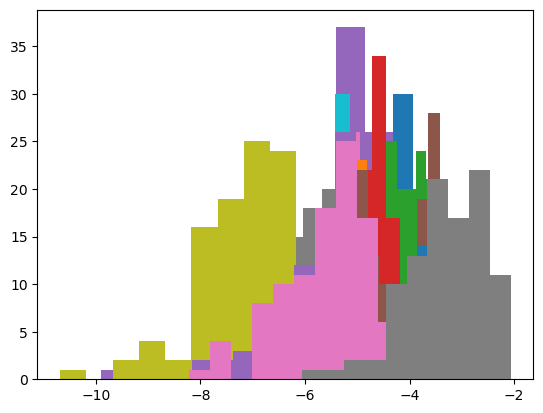

In [12]:
for event in range(len(obsdata)):
    plt.hist(np.log(p_theta[event]))

In [8]:
prob_test

inf

In [3]:
submodels_dict = {0: {0: 'chi00', 1: 'chi01', 2: 'chi02', 3: 'chi05'}, 1: {0: 'alpha02', 1: 'alpha05', 2: 'alpha10', 3: 'alpha20', 4: 'alpha50'}}
smallest_N=100000


prob = np.zeros((20,5))
for seed in range(5):
    np.random.seed(seed)
    observations, obsdata, p_theta, events = gw_obs.generate_observations(params, gw_path, \
                                            100, 'posteriors', 'p_theta_jcb')
    #for e, event in enumerate(obsdata):
    for i, chib in enumerate(tqdm(np.linspace(0,0.1,20))):
        x = [chib,4.8,0.8,0.05,0.01,0.05]
        prob[i,seed] = (lnlike_cont(x, obsdata, flow, submodels_dict, channels, p_theta, smallest_N))

  0%|          | 0/20 [00:00<?, ?it/s]

tensor([[ 3.1860e+01,  8.8251e-01, -9.3051e-03,  1.9724e-01],
        [ 3.1781e+01,  6.9035e-01,  1.8339e-01,  3.1552e-01]])
tensor([[0.0000, 1.5686],
        [0.0000, 1.5686]])


/Users/stormcolloms/Documents/PhD/Project_work/AMAZE_model_selection/populations/Flowsclass_dev.py:500: RuntimeWarning: divide by zero encountered in log
  likelihoods_per_samp[event] = likelihoods_per_samp[event] - np.log(prior_pdf[event])


(68,)
tensor([[ 3.1860e+01,  8.8251e-01, -9.3051e-03,  1.9724e-01],
        [ 3.1781e+01,  6.9035e-01,  1.8339e-01,  3.1552e-01]])
tensor([[0.],
        [0.]])
(68,)
tensor([[ 3.1860e+01,  8.8251e-01, -9.3051e-03,  1.9724e-01],
        [ 3.1781e+01,  6.9035e-01,  1.8339e-01,  3.1552e-01]])
tensor([[0.],
        [0.]])
(68,)
tensor([[ 3.1860e+01,  8.8251e-01, -9.3051e-03,  1.9724e-01],
        [ 3.1781e+01,  6.9035e-01,  1.8339e-01,  3.1552e-01]])
tensor([[0.],
        [0.]])
(68,)
tensor([[ 3.1860e+01,  8.8251e-01, -9.3051e-03,  1.9724e-01],
        [ 3.1781e+01,  6.9035e-01,  1.8339e-01,  3.1552e-01]])
tensor([[0.],
        [0.]])


  5%|▌         | 1/20 [00:59<18:53, 59.64s/it]

...

(68,)
tensor([[29.5164,  0.6636,  0.1045,  0.2954],
        [36.4115,  0.6541,  0.2569,  0.1052]])
tensor([[0.0947, 1.5686],
        [0.0947, 1.5686]])
(68,)
tensor([[29.5164,  0.6636,  0.1045,  0.2954],
        [36.4115,  0.6541,  0.2569,  0.1052]])
tensor([[0.0947],
        [0.0947]])
(68,)
tensor([[29.5164,  0.6636,  0.1045,  0.2954],
        [36.4115,  0.6541,  0.2569,  0.1052]])
tensor([[0.0947],
        [0.0947]])
(68,)
tensor([[29.5164,  0.6636,  0.1045,  0.2954],
        [36.4115,  0.6541,  0.2569,  0.1052]])
tensor([[0.0947],
        [0.0947]])
(68,)
tensor([[29.5164,  0.6636,  0.1045,  0.2954],
        [36.4115,  0.6541,  0.2569,  0.1052]])
tensor([[0.0947],
        [0.0947]])


 95%|█████████▌| 19/20 [19:40<00:59, 59.96s/it]

(68,)
tensor([[29.5164,  0.6636,  0.1045,  0.2954],
        [36.4115,  0.6541,  0.2569,  0.1052]])
tensor([[0.1000, 1.5686],
        [0.1000, 1.5686]])
(68,)
tensor([[29.5164,  0.6636,  0.1045,  0.2954],
        [36.4115,  0.6541,  0.2569,  0.1052]])
tensor([[0.1000],
        [0.1000]])
(68,)
tensor([[29.5164,  0.6636,  0.1045,  0.2954],
        [36.4115,  0.6541,  0.2569,  0.1052]])
tensor([[0.1000],
        [0.1000]])
(68,)
tensor([[29.5164,  0.6636,  0.1045,  0.2954],
        [36.4115,  0.6541,  0.2569,  0.1052]])
tensor([[0.1000],
        [0.1000]])
(68,)
tensor([[29.5164,  0.6636,  0.1045,  0.2954],
        [36.4115,  0.6541,  0.2569,  0.1052]])
tensor([[0.1000],
        [0.1000]])


100%|██████████| 20/20 [20:40<00:00, 62.01s/it]

(68,)


In [4]:
prob

array([[inf, inf, inf, inf, inf],
       [inf, inf, inf, inf, inf],
       [inf, inf, inf, inf, inf],
       [inf, inf, inf, inf, inf],
       [inf, inf, inf, inf, inf],
       [inf, inf, inf, inf, inf],
       [inf, inf, inf, inf, inf],
       [inf, inf, inf, inf, inf],
       [inf, inf, inf, inf, inf],
       [inf, inf, inf, inf, inf],
       [inf, inf, inf, inf, inf],
       [inf, inf, inf, inf, inf],
       [inf, inf, inf, inf, inf],
       [inf, inf, inf, inf, inf],
       [inf, inf, inf, inf, inf],
       [inf, inf, inf, inf, inf],
       [inf, inf, inf, inf, inf],
       [inf, inf, inf, inf, inf],
       [inf, inf, inf, inf, inf],
       [inf, inf, inf, inf, inf]])